# 04 — Predictive Modeling: Albania 2022 + Out-of-Sample

Compares the model zoo on the Albania 2022 cohort (repeated stratified CV, weighted) and runs the out-of-sample experiment (train 2009–2018 → test 2022).

**Reproducibility note.** scikit-learn (`libgomp`) and the gradient boosters (`libomp`) can abort a single process on macOS if both load together. So this notebook runs **scikit-learn models live in-kernel**, and **loads the booster CV rows** from the CSV produced by `scripts/run_model_comparison.py` (which runs boosters in their own process). The out-of-sample cell is lightweight and runs live.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")  # macOS duplicate OpenMP guard
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)

In [2]:
from src.models.prepare import build_model_data
from src.models.experiment import compare_models_cv

df = pd.read_parquet('../data/processed/alb_2022.parquet')
feats = ['ESCS','HOMEPOS','GENDER','REPEAT','IMMIG','BELONG','TEACHSUP',
         'ICTHOME','ICTSCH','ANXMAT','GRADE','HISCED','HISEI']
data = build_model_data(df, feats, domain='math')
print(data.meta)
print('Features:', data.feature_names)

2026-06-30 18:13:22 [info     ] Point target added             at_risk_rate=0.754 domain=math threshold=420.07


2026-06-30 18:13:22 [info     ] Feature selection complete     n_features=13


2026-06-30 18:13:22 [info     ] Model data built               at_risk_rate=0.7536 domain=math n_countries=1 n_features=25 n_samples=6129 target_col=AT_RISK_MATH weights_normalized=False


{'domain': 'math', 'n_samples': 6129, 'n_features': 25, 'n_countries': 1, 'weights_normalized': False, 'at_risk_rate': 0.7536, 'target_col': 'AT_RISK_MATH'}
Features: ['ESCS', 'HOMEPOS', 'GENDER', 'REPEAT', 'IMMIG', 'BELONG', 'TEACHSUP', 'ICTHOME', 'ICTSCH', 'ANXMAT', 'GRADE', 'HISCED', 'HISEI', '_MISS_ESCS', '_MISS_HOMEPOS', '_MISS_REPEAT', '_MISS_IMMIG', '_MISS_BELONG', '_MISS_TEACHSUP', '_MISS_ICTHOME', '_MISS_ICTSCH', '_MISS_ANXMAT', '_MISS_GRADE', '_MISS_HISCED', '_MISS_HISEI']


## 1. scikit-learn model comparison (live, 5×4 repeated stratified CV)

Weighted, leakage-safe (median imputation per fold). Boosters added in the next cell.

In [3]:
sklearn_models = ['logistic_regression','decision_tree','random_forest',
                  'extra_trees','gradient_boosting']
res_sklearn = compare_models_cv(data, sklearn_models, outer_folds=5, outer_repeats=4)
res_sklearn[['model','roc_auc_mean','roc_auc_std','pr_auc_mean','f1_macro_mean','mcc_mean']]

  [done] logistic_regression: AUC=0.7260 (23s)


2026-06-30 18:13:46 [info     ] Model compared                 auc=0.726 model=logistic_regression


  [done] decision_tree: AUC=0.5684 (2s)


2026-06-30 18:13:48 [info     ] Model compared                 auc=0.5684 model=decision_tree


  [done] random_forest: AUC=0.7097 (5s)


...

  [done] extra_trees: AUC=0.7070 (5s)


2026-06-30 18:13:58 [info     ] Model compared                 auc=0.707 model=extra_trees


  [done] gradient_boosting: AUC=0.7268 (40s)


2026-06-30 18:14:38 [info     ] Model compared                 auc=0.7268 model=gradient_boosting


,model,roc_auc_mean,roc_auc_std,pr_auc_mean,f1_macro_mean,mcc_mean
0,gradient_boosting,0.7268,0.0137,0.8780,0.6091,0.2832
1,logistic_regression,0.7260,0.0210,0.8819,0.6255,0.2783
2,random_forest,0.7097,0.0152,0.8679,0.5992,0.2611
3,extra_trees,0.7070,0.0166,0.8659,0.6077,0.2595
4,decision_tree,0.5684,0.0179,0.7802,0.5673,0.1349


## 2. Full comparison incl. boosters

Booster rows come from `outputs/results/albania_2022_model_comparison.csv` (generated by `python scripts/run_model_comparison.py`). We display the merged master table.

In [4]:
full = pd.read_csv('../outputs/results/albania_2022_model_comparison.csv')
full[['model','roc_auc_mean','roc_auc_std','pr_auc_mean','f1_macro_mean','mcc_mean']]

,model,roc_auc_mean,roc_auc_std,pr_auc_mean,f1_macro_mean,mcc_mean
0,catboost,0.7314,0.0156,0.8796,0.6471,0.3045
1,gradient_boosting,0.7268,0.0137,0.8780,0.6091,0.2832
2,logistic_regression,0.7260,0.0210,0.8819,0.6255,0.2783
3,random_forest,0.7097,0.0152,0.8679,0.5992,0.2611
4,extra_trees,0.7070,0.0166,0.8659,0.6077,0.2595
5,xgboost,0.6982,0.0148,0.8634,0.6166,0.2615
6,naive_bayes,0.6819,0.0202,0.8458,0.5994,0.2460
7,knn,0.6639,0.0222,0.8423,0.5878,0.2145
8,decision_tree,0.5684,0.0179,0.7802,0.5673,0.1349


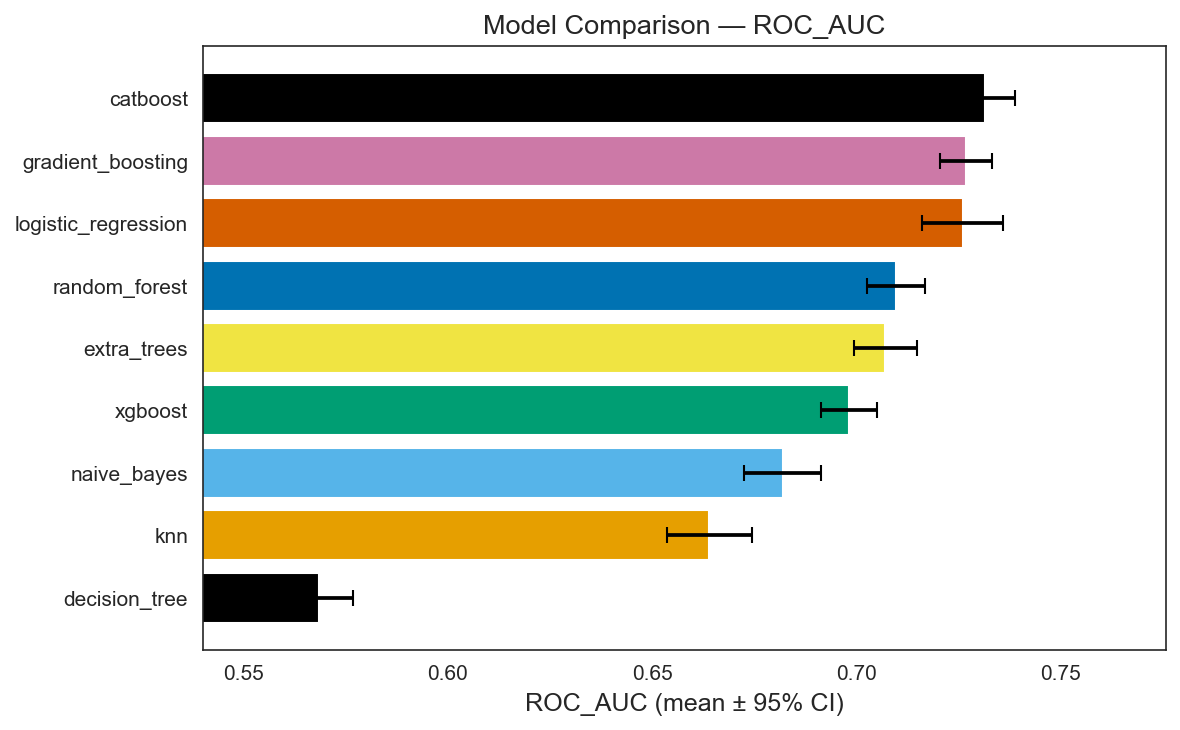

In [5]:
from src.visualization.model_plots import plot_cv_distribution
fig = plot_cv_distribution(full, metric='roc_auc'); plt.show()

**Reading:** CatBoost and Gradient Boosting lead (AUC ≈ 0.72); Logistic Regression is a strong, interpretable baseline (0.70). Decision Tree trails badly (0.57).

## 3. Out-of-sample experiment (train 2009–2018 → test 2022)

Tests whether models trained on the historical, improving period generalize to the 2022 crisis cohort. Lightweight (single fits) so it runs live; thread-limited for OpenMP safety.

In [6]:
from src.models.experiment import out_of_sample
long = pd.read_parquet('../data/processed/albania_longitudinal.parquet')
train = long[long.CYCLE.isin([2009,2012,2015,2018])]; test = long[long.CYCLE==2022]
oos_feats = ['ESCS','HOMEPOS','GENDER','REPEAT','IMMIG','BELONG','TEACHSUP','ANXMAT','GRADE','HISCED','HISEI']
# scikit-learn models live; boosters were added via the script (see JSON below)
res = out_of_sample(train, test, oos_feats,
                    ['logistic_regression','random_forest','extra_trees','gradient_boosting'],
                    domain='math')
pd.DataFrame({m: {'test_AUC': d['roc_auc']} for m, d in res['models'].items()}).T

2026-06-30 18:14:38 [info     ] Point target added             at_risk_rate=0.558 domain=math threshold=420.07


2026-06-30 18:14:38 [info     ] Feature selection complete     n_features=11


2026-06-30 18:14:38 [info     ] Model data built               at_risk_rate=0.5576 domain=math n_countries=1 n_features=21 n_samples=20913 target_col=AT_RISK_MATH weights_normalized=False


2026-06-30 18:14:38 [info     ] Point target added             at_risk_rate=0.754 domain=math threshold=420.07


2026-06-30 18:14:38 [info     ] Feature selection complete     n_features=11


...

  [oos] extra_trees: test_AUC=0.6631 (weighted)


2026-06-30 18:14:55 [info     ] OOS evaluated                  model=extra_trees test_auc=0.6631


  [oos] gradient_boosting: test_AUC=0.6741 (weighted)


2026-06-30 18:15:04 [info     ] OOS evaluated                  model=gradient_boosting test_auc=0.6741


,test_AUC
logistic_regression,0.6193
random_forest,0.6738
extra_trees,0.6631
gradient_boosting,0.6741


In [7]:
# Full OOS results (all 7 models) from the saved experiment JSON
import json
oos = json.load(open('../outputs/results/oos_2022_experiment.json'))
ok = {m: d for m, d in oos['models'].items() if 'roc_auc' in d}
failed = [m for m, d in oos['models'].items() if 'error' in d]
if failed: print('models unavailable (local libomp install):', failed)
pd.DataFrame({m: {'test_AUC': d['roc_auc'], 'PR_AUC': d['pr_auc'], 'MCC': d['mcc']}
              for m, d in ok.items()}).T.sort_values('test_AUC', ascending=False)

models unavailable (local libomp install): ['lightgbm']


,test_AUC,PR_AUC,MCC
gradient_boosting,0.6741,0.8533,0.2236
random_forest,0.6738,0.8495,0.2092
catboost,0.6648,0.8486,0.2080
extra_trees,0.6631,0.8439,0.1931
xgboost,0.6386,0.8311,0.1840
logistic_regression,0.6193,0.8386,0.0073


## 4. Rigorous PV evaluation — Rubin's rules

The comparison above uses the PV-mean point target (cheap, standard for model *selection*). For the headline number we instead fit the winning model **once per plausible value** and combine the 10 estimates with Rubin's rules — the correct PISA methodology. The reported SE and CI then include the between-PV (imputation) uncertainty, and FMI is the fraction of missing information due to PV draw.

In [8]:
from src.models.experiment import per_pv_cv_evaluate
pv = per_pv_cv_evaluate(df, feats, 'gradient_boosting', domain='math',
                        outer_folds=5, outer_repeats=2)
auc = pv['roc_auc']
print(f"PV-combined AUC = {auc['estimate']:.4f}  "
      f"(95% CI {auc['ci95_low']:.4f}-{auc['ci95_high']:.4f}, FMI={auc['fmi']:.3f}, n_PV={auc['n_pv']})")
pd.DataFrame({k: pv[k] for k in ['roc_auc','pr_auc','f1_macro','mcc'] if k in pv}).T[['estimate','se','fmi']]

2026-06-30 18:15:04 [info     ] Point target added             at_risk_rate=0.754 domain=math threshold=420.07


2026-06-30 18:15:04 [info     ] Feature selection complete     n_features=13


2026-06-30 18:15:04 [info     ] Model data built               at_risk_rate=0.7536 domain=math n_countries=1 n_features=25 n_samples=6129 target_col=AT_RISK_MATH weights_normalized=False


  [pv] PV1MATH: AUC=0.7120


  [pv] PV2MATH: AUC=0.7237


...

  [pv] PV9MATH: AUC=0.7226


  [pv] PV10MATH: AUC=0.7145


2026-06-30 18:18:17 [info     ] Per-PV Rubin evaluation complete auc=0.7163 model=gradient_boosting


PV-combined AUC = 0.7163  (95% CI 0.7016-0.7310, FMI=0.391, n_PV=10)


,estimate,se,fmi
roc_auc,0.7163,0.0075,0.3911
pr_auc,0.8659,0.0051,0.4907
f1_macro,0.5965,0.0072,0.5605
mcc,0.2647,0.0146,0.5911


**Reading:** the Rubin-combined AUC is close to the point-target CV AUC (the PV draw adds modest uncertainty, captured by FMI). This confirms the model ranking is not an artefact of collapsing the plausible values.

**Takeaway:** out-of-sample AUC falls to ~0.64–0.67 for every model. The covariate shift (notebook 03, detection AUC 0.98) is real and degrades transfer, but no model fully collapses — the 2022 risk structure shifted yet remains partly predictable from history.